In [1]:
# import libraries and other configurations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

warnings.filterwarnings("ignore")

RANDOM_STATE = 121

In [2]:
# Load dataset
df = pd.read_csv(
    "../data/processed/cleaned_donor_data.csv",
)

In [3]:
# Verify dataset loaded correctly
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (34403, 19)


,donor_unique_id,donor_postal_code,donor_age,gender_identity,is_member_flag,is_alumnus_flag,is_parent_flag,has_involvement_flag,preferred_address_type,has_email_flag,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,donor_indicator_flag
0,1,23187.0,42,Female,0,0,0,0,Home,0,1,0.0,0.0,0.0,0.0,0.0,0.0,10.0,1
1,2,77643.0,33,Female,0,1,0,1,NaN,1,0,0.0,0.0,0.0,0.0,0.0,0.0,2100.0,1
2,3,NaN,42,Female,0,0,0,0,Home,0,1,0.0,0.0,0.0,0.0,0.0,200.0,200.0,1
3,4,47141.0,31,Female,0,1,0,1,Home,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,92555.0,68,Female,0,0,0,0,Home,1,0,0.0,0.0,0.0,0.0,0.0,0.0,505.0,1


In [4]:
# Verify dataset loaded correctly
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   donor_unique_id               34403 non-null  int64  
 1   donor_postal_code             34312 non-null  float64
 2   donor_age                     34403 non-null  int64  
 3   gender_identity               33912 non-null  str    
 4   is_member_flag                34403 non-null  int64  
 5   is_alumnus_flag               34403 non-null  int64  
 6   is_parent_flag                34403 non-null  int64  
 7   has_involvement_flag          34403 non-null  int64  
 8   preferred_address_type        30370 non-null  str    
 9   has_email_flag                34403 non-null  int64  
 10  consecutive_donor_years       34403 non-null  int64  
 11  last_fiscal_year_donation     34403 non-null  float64
 12  donation_2_fiscal_years_ago   34403 non-null  float64
 13  donation_3_f

In [5]:
# Verify dataset loaded correctly
df.sample(10, random_state=RANDOM_STATE)

,donor_unique_id,donor_postal_code,donor_age,gender_identity,is_member_flag,is_alumnus_flag,is_parent_flag,has_involvement_flag,preferred_address_type,has_email_flag,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,donor_indicator_flag
33267,33371,42301.0,46,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
26595,26683,45620.0,42,Female,0,0,0,0,Home,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
16653,16704,33427.0,28,Female,0,0,0,0,Home,0,0,0.0,120.0,0.0,0.0,0.0,0.0,120.0,1
21428,21498,54131.0,33,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
16873,16924,90265.0,33,Male,0,1,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19919,19982,54459.0,32,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
15478,15527,64686.0,42,Male,0,0,0,0,Home,0,8,0.0,0.0,10.0,0.0,0.0,0.0,9680.0,1
591,596,12067.0,42,Female,0,0,1,0,Home,0,0,0.0,100.0,1.0,0.0,0.0,0.0,101.0,1
1474,1483,90265.0,42,Female,0,1,0,0,Home,1,0,0.0,0.0,0.0,0.0,0.0,0.0,479.0,1
22846,22922,45856.0,36,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [6]:
# Verify dataset loaded correctly
df.isna().sum().sort_values(ascending=False).head(10)

preferred_address_type          4033
gender_identity                  491
donor_postal_code                 91
donor_unique_id                    0
last_fiscal_year_donation          0
cumulative_donation_amount         0
current_fiscal_year_donation       0
donation_5_fiscal_years_ago        0
donation_4_fiscal_years_ago        0
donation_3_fiscal_years_ago        0
dtype: int64

In [7]:
# Dataset Shape
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 34,403
Columns: 19


In [8]:
# Data Types Summary
dtype_summary = (
    df.dtypes
      .astype(str)
      .value_counts()
      .reset_index()
)

dtype_summary.columns = ["Data Type", "Count"]
dtype_summary

,Data Type,Count
0,int64,9
1,float64,8
2,str,2


In [9]:
# Numerical Variables
numeric_cols = df.select_dtypes(
    include=["int64", "float64", "Int64"]
).columns.tolist()

print(f"Numeric Variables: {len(numeric_cols)}")
print("-" * 40)
print(numeric_cols)

Numeric Variables: 17
----------------------------------------
['donor_unique_id', 'donor_postal_code', 'donor_age', 'is_member_flag', 'is_alumnus_flag', 'is_parent_flag', 'has_involvement_flag', 'has_email_flag', 'consecutive_donor_years', 'last_fiscal_year_donation', 'donation_2_fiscal_years_ago', 'donation_3_fiscal_years_ago', 'donation_4_fiscal_years_ago', 'donation_5_fiscal_years_ago', 'current_fiscal_year_donation', 'cumulative_donation_amount', 'donor_indicator_flag']


In [10]:
# Categorical Variables
categorical_cols = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print(f"Categorical Variables: {len(categorical_cols)}")
print("-" * 40)
print(categorical_cols)

Categorical Variables: 2
----------------------------------------
['gender_identity', 'preferred_address_type']


In [11]:
# Memory Usage
memory_mb = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage: {memory_mb:.2f} MB")

Memory Usage: 5.28 MB


## Dataset Overview Observations

### Dataset Summary
- The cleaned dataset contains 34,403 donor records and 19 features.
- Compared to the original dataset, 105 records were removed during cleaning and four features were removed due to excessive missingness.

### Feature Composition
- The dataset contains a mixture of demographic information, engagement indicators, donor history variables, and donation amount variables.
- Most variables are numerical due to the conversion of binary `Y/N` indicators into '1/0' values during data cleaning.

### EDA Focus
- The primary goal of this phase is to identify patterns within donor demographics, engagement behavior, and historical donation activity that may help inform future donor propensity modeling and business outreach strategies.

In [12]:
# Historical Donor Distribution Counts
donor_status_counts = df["donor_indicator_flag"].value_counts()

donor_status_counts

donor_indicator_flag
1    21369
0    13034
Name: count, dtype: int64

In [13]:
# Historical Donor Distribution Percentage
donor_status_pct = (
    df["donor_indicator_flag"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

donor_status_pct

donor_indicator_flag
0    37.89
1    62.11
Name: proportion, dtype: float64

In [14]:
# Historical Donor Distribution Summary
donor_status_summary = pd.DataFrame({
    "Count": df["donor_indicator_flag"].value_counts(),
    "Percent": (
        df["donor_indicator_flag"]
        .value_counts(normalize=True)
        .map(lambda x: f"{x * 100:.2f}%")
    ).round(2)
})

donor_status_summary

,Count,Percent
donor_indicator_flag,,
1,21369,62.11%
0,13034,37.89%


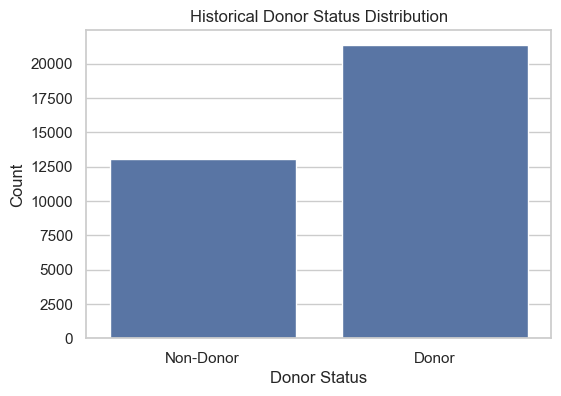

In [15]:
# Historical Donor Distribution Count Bar Graph
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="donor_indicator_flag"
)

plt.xticks(
    [0,1],
    ["Non-Donor","Donor"]
)

plt.title("Historical Donor Status Distribution")
plt.xlabel("Donor Status")
plt.ylabel("Count")

plt.show()

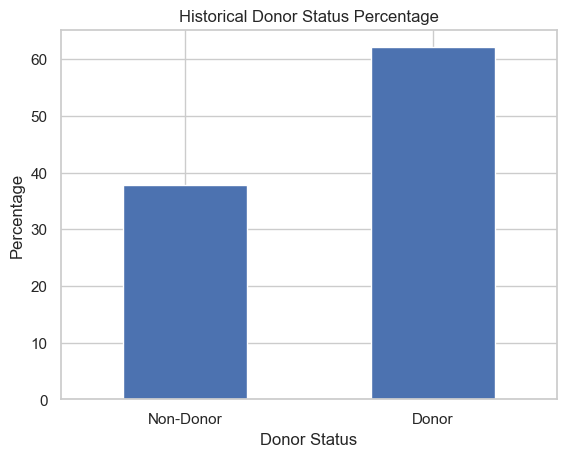

In [16]:
# Historical Donor Distribution Percentage Bar Graph
donor_status_pct.plot(
    kind="bar"
)

plt.title("Historical Donor Status Percentage")
plt.xlabel("Donor Status")
plt.ylabel("Percentage")

plt.xticks(
    [0,1],
    ["Non-Donor","Donor"],
    rotation=0
)

plt.show()

## Historical Donor Status Observations

- Approximately 62.11% of constituents in the dataset are classified as historical donors, while 37.89% are non-donors. 
- While historical donors make up the majority of the dataset, both groups are well-represented. The strong sample size ensures that any comparisons we make during analysis will be highly reliable and statistically sound.

In [17]:
# Summary Statistics
numeric_features = [
    "donor_age",
    "consecutive_donor_years",
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "current_fiscal_year_donation",
    "cumulative_donation_amount"
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
donor_age,34403.0,43.474523,11.253489,16.0,42.0,42.0,42.0,110.0
consecutive_donor_years,34403.0,1.140337,2.423796,0.0,0.0,0.0,1.0,36.0
last_fiscal_year_donation,34403.0,378.745051,54130.784361,0.0,0.0,0.0,0.0,10000000.0
donation_2_fiscal_years_ago,34403.0,96.470744,10470.654405,0.0,0.0,0.0,0.0,1932960.0
donation_3_fiscal_years_ago,34403.0,63.932651,3287.198708,0.0,0.0,0.0,0.0,500000.0
donation_4_fiscal_years_ago,34403.0,57.276865,2598.510659,0.0,0.0,0.0,0.0,250000.0
donation_5_fiscal_years_ago,34403.0,127.010406,10079.734632,0.0,0.0,0.0,0.0,1250000.0
current_fiscal_year_donation,34403.0,198.298230,15874.730174,0.0,0.0,0.0,0.0,2000000.0
cumulative_donation_amount,34403.0,2369.563032,113974.865206,0.0,0.0,25.0,144.0,12221854.0


In [18]:
# Check for skew
skewness = pd.DataFrame({
    "Skew": df[numeric_features].skew()
})

skewness

,Skew
donor_age,1.570798
consecutive_donor_years,5.096505
last_fiscal_year_donation,183.325822
donation_2_fiscal_years_ago,182.924265
donation_3_fiscal_years_ago,117.862735
donation_4_fiscal_years_ago,76.343381
donation_5_fiscal_years_ago,114.285712
current_fiscal_year_donation,118.476951
cumulative_donation_amount,94.307673


In [19]:
# Variables with the highest skew
df[numeric_features].max().sort_values(ascending=False)

cumulative_donation_amount      12221854.0
last_fiscal_year_donation       10000000.0
current_fiscal_year_donation     2000000.0
donation_2_fiscal_years_ago      1932960.0
donation_5_fiscal_years_ago      1250000.0
donation_3_fiscal_years_ago       500000.0
donation_4_fiscal_years_ago       250000.0
donor_age                            110.0
consecutive_donor_years               36.0
dtype: float64

In [20]:
# Top donors
df.nlargest(
    10,
    "cumulative_donation_amount"
)[[
    "donor_unique_id",
    "cumulative_donation_amount",
    "last_fiscal_year_donation",
    "current_fiscal_year_donation"
]]

,donor_unique_id,cumulative_donation_amount,last_fiscal_year_donation,current_fiscal_year_donation
2163,2173,12221854.0,500000.0,2000000.0
33952,34057,12221854.0,500000.0,2000000.0
18349,18405,10200574.0,10000000.0,300.0
23802,23884,3455188.0,0.0,92100.0
1316,1325,2440460.0,500000.0,4500.0
27150,27238,2392920.0,90000.0,27000.0
10534,10572,1594286.0,0.0,0.0
20813,20879,1594286.0,0.0,0.0
9440,9475,1510000.0,0.0,10000.0
25609,25695,1500000.0,0.0,0.0


In [21]:
# Sanity check 
# Check whether two donors coincidentally have the same cumulative_donation_amount
# or if this represents a duplicate donor anomaly that needs to be resolved
df[df["cumulative_donation_amount"] == 12221854]

,donor_unique_id,donor_postal_code,donor_age,gender_identity,is_member_flag,is_alumnus_flag,is_parent_flag,has_involvement_flag,preferred_address_type,has_email_flag,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,donor_indicator_flag
2163,2173,47175.0,99,Female,0,1,0,1,Home,0,6,500000.0,0.0,500000.0,0.0,100.0,2000000.0,12221854.0,1
33952,34057,72034.0,88,Female,0,1,0,0,Home,0,16,500000.0,3000.0,199842.0,200.0,0.0,2000000.0,12221854.0,1


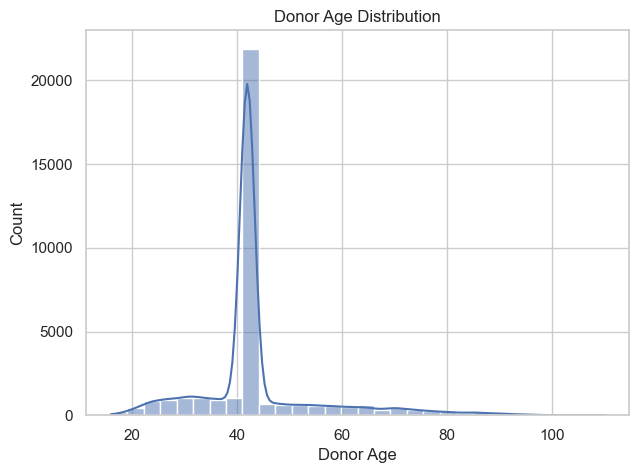

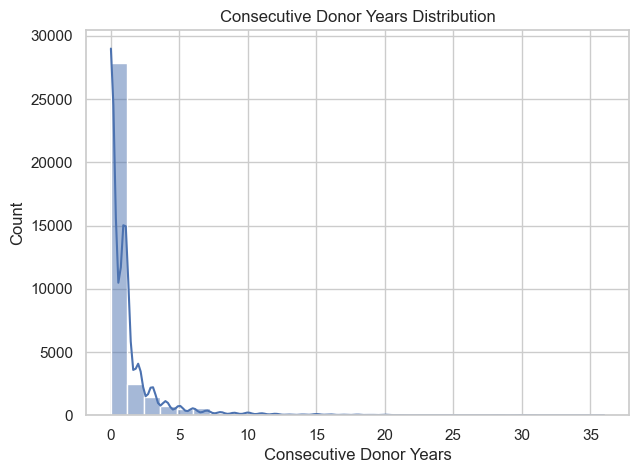

In [22]:
# Demographic Variables KDE
demographic_features = [
    "donor_age",
    "consecutive_donor_years"
]

for column in demographic_features:
    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(f"{column.replace('_', ' ').title()} Distribution")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Count")

    plt.show()

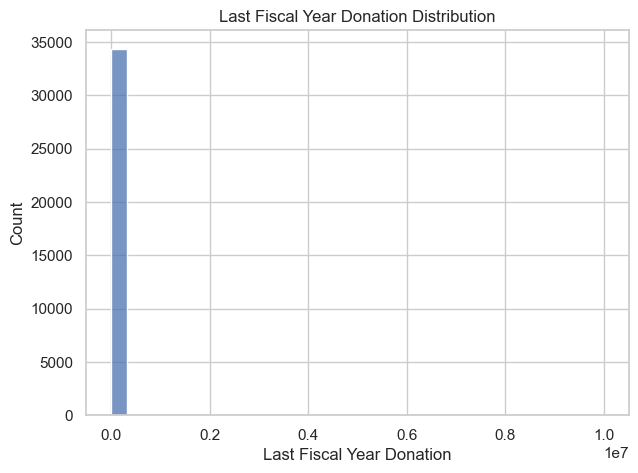

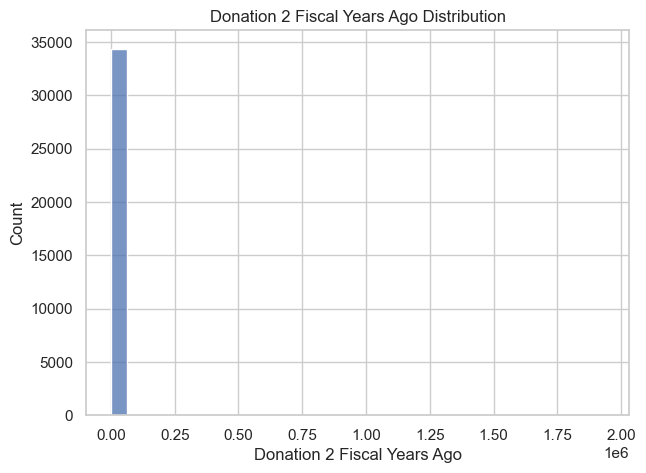

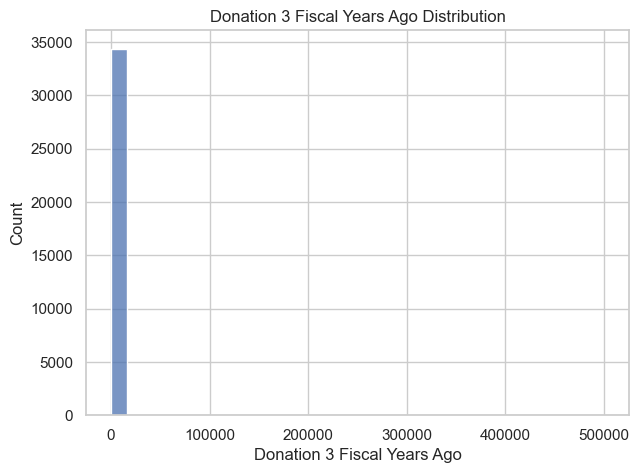

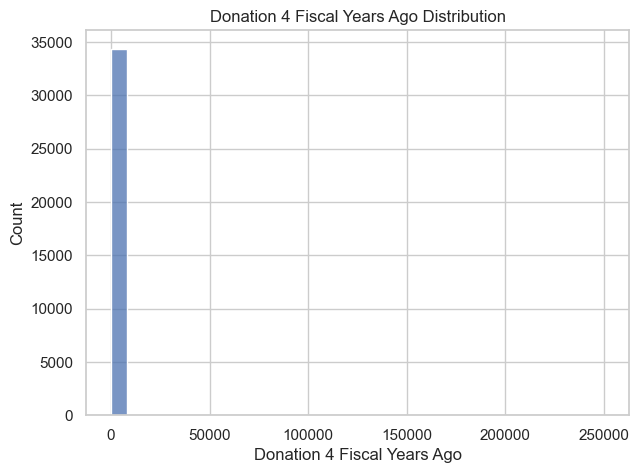

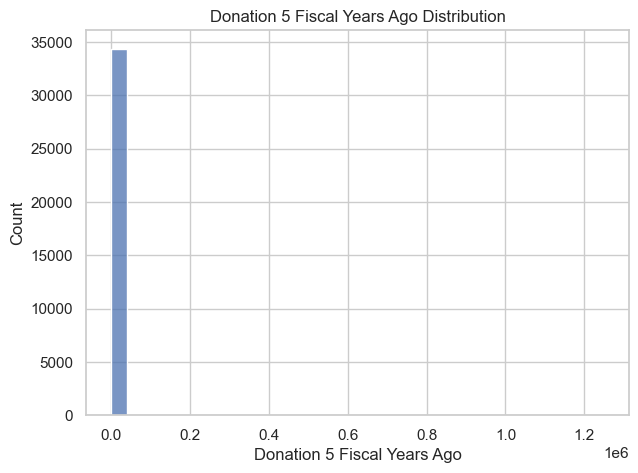

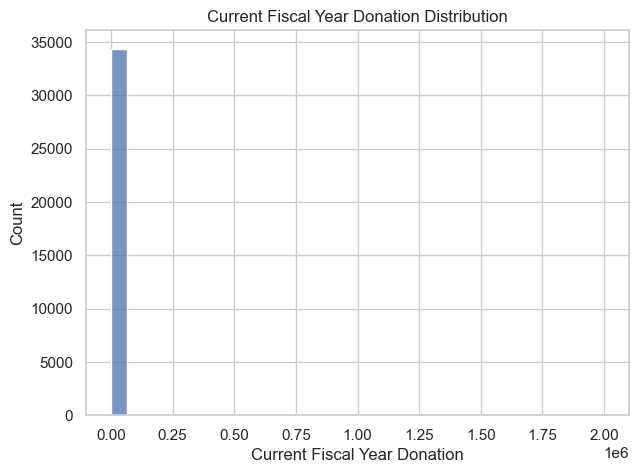

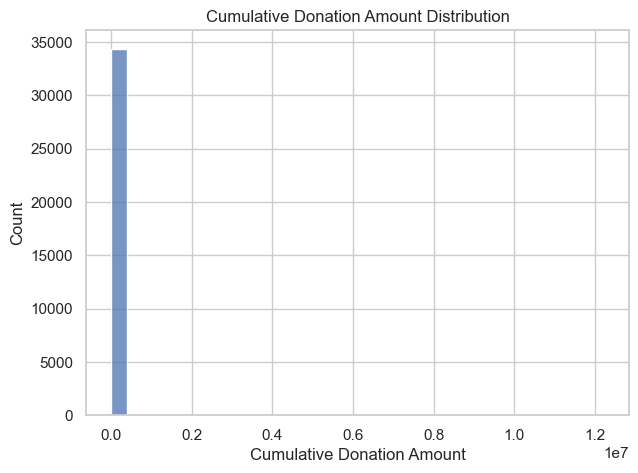

In [23]:
# Donation Variables Histogram
donation_features = [
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "current_fiscal_year_donation",
    "cumulative_donation_amount"
]

for column in donation_features:
    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=30
    )

    plt.title(f"{column.replace('_', ' ').title()} Distribution")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Count")

    plt.show()

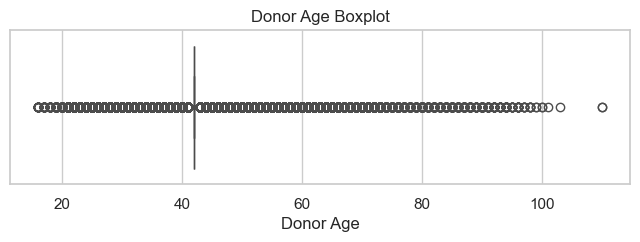

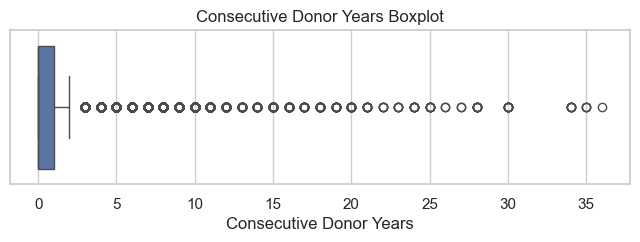

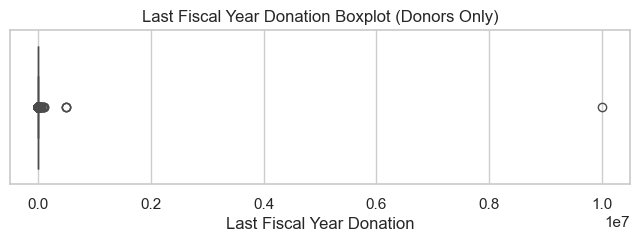

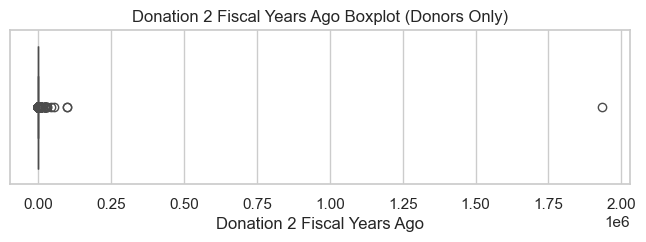

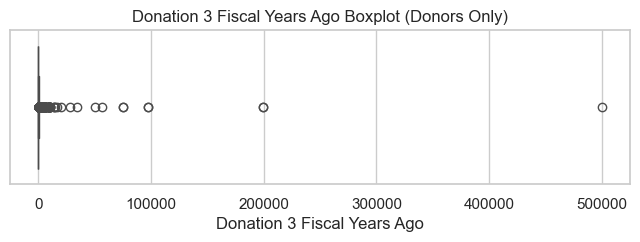

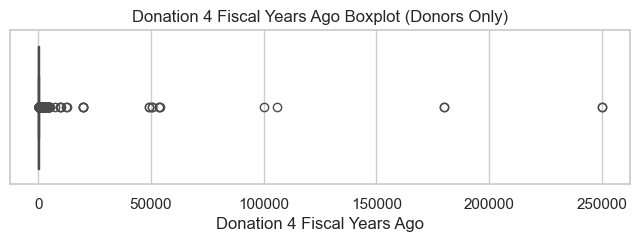

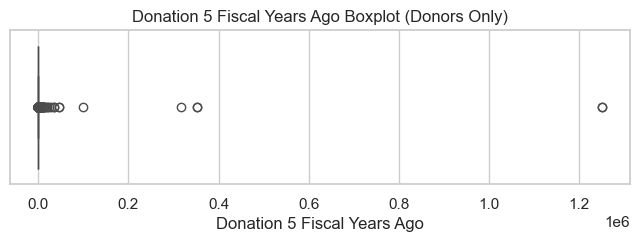

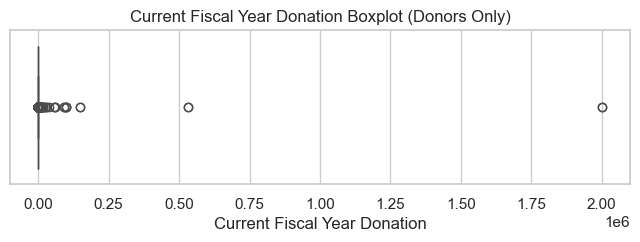

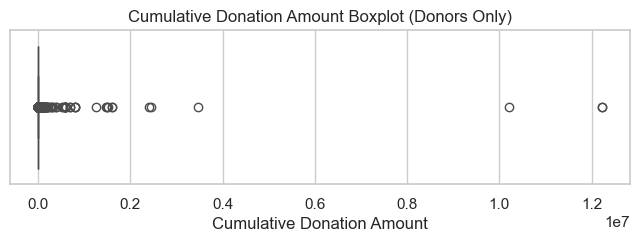

In [24]:
# Boxplots
for column in numeric_features:
    plt.figure(figsize=(8, 2))

    if "donation" in column or "amount" in column:
        plot_data = df.loc[df[column] > 0, column]
        title_suffix = " (Donors Only)"
    else:
        plot_data = df[column]
        title_suffix = ""

    sns.boxplot(x=plot_data)

    plt.title(f"{column.replace('_', ' ').title()} Boxplot{title_suffix}")
    plt.xlabel(column.replace("_", " ").title())

    plt.show()

## Boxplot Observations

### `donor_age`
- The `donor_age` variable exhibits relatively few outliers. Most constituents are concentrated around the median age of 42 years, while a small number of older donors appear as expected high-value observations.

### `consecutive_donor_years`
- The `consecutive_donor_years` variable contains numerous high-value outliers representing long-term donor loyalty

### Donation Amount Variables
- The majority of donation amounts are relatively small
- All donation amount variables contain substantial positive outliers, a limited number of major gifts extend into the hundreds of thousands or millions of dollars.
  - Inspection of the largest donation records indicates that these observations correspond to genuine major donors rather than obvious data quality issues.
- These observations contribute to the strong positive skew observed across all donation variables and reflect the typical donation distribution of nonprofit fundraising datasets.

In [25]:
# Donation participation
donation_columns = [
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "current_fiscal_year_donation"
]

participation = pd.DataFrame({
    "Donors": (df[donation_columns] > 0).sum(),
    "Percent": ((df[donation_columns] > 0).mean() * 100).round(2)
})

participation

,Donors,Percent
last_fiscal_year_donation,2358,6.85
donation_2_fiscal_years_ago,2463,7.16
donation_3_fiscal_years_ago,2533,7.36
donation_4_fiscal_years_ago,2143,6.23
donation_5_fiscal_years_ago,1961,5.70
current_fiscal_year_donation,1904,5.53


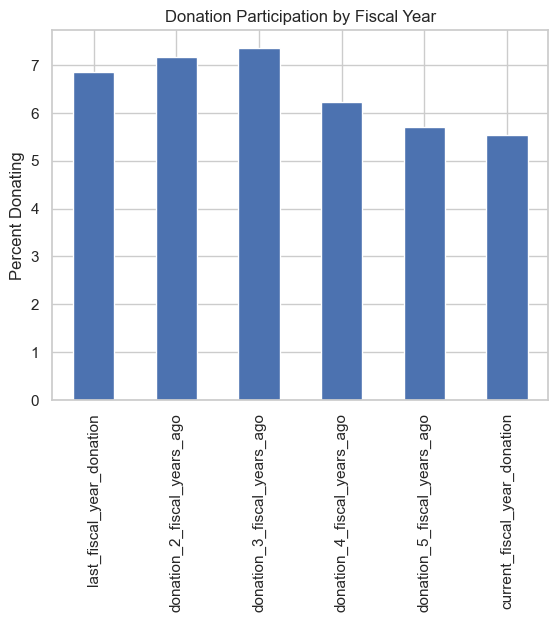

In [26]:
# Annual donation rates
participation["Percent"].plot(kind="bar")

plt.ylabel("Percent Donating")
plt.title("Donation Participation by Fiscal Year")

plt.show()

In [27]:
# Count how many years each donor has made a donation; Recurring donor
has_donated_yearly = df[donation_columns] > 0
df["Years Donated"] = has_donated_yearly.sum(axis=1)

donation_years_distribution = (
    df["Years Donated"]
    .value_counts()
    .sort_index()
    .to_frame(name="Donor Count")
)

donation_years_distribution

,Donor Count
Years Donated,
0,23920
1,8195
2,1807
3,398
4,62
5,15
6,6


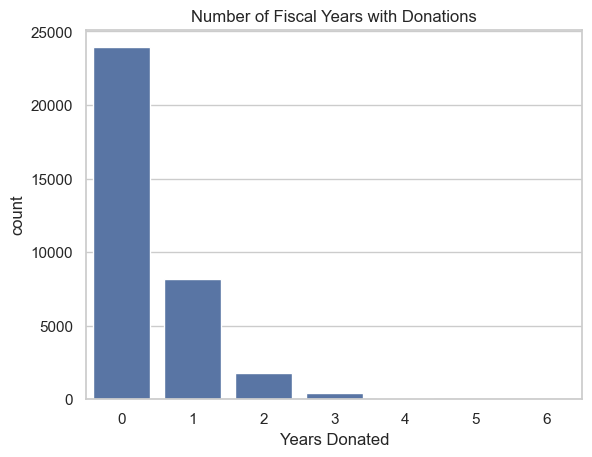

In [28]:
# Recurring donor bar graph 
sns.countplot(
    data=df,
    x="Years Donated"
)

plt.title("Number of Fiscal Years with Donations")

plt.show()

In [29]:
# Summary stats for cumulative donation amount
df["cumulative_donation_amount"].describe()

count    3.440300e+04
mean     2.369563e+03
std      1.139749e+05
min      0.000000e+00
25%      0.000000e+00
50%      2.500000e+01
75%      1.440000e+02
max      1.222185e+07
Name: cumulative_donation_amount, dtype: float64

In [30]:
# How much donors are in the top 1%
active_donors = df[df["cumulative_donation_amount"] > 0]

top_1_percent_count = max(1, round(len(active_donors) * 0.01))

print(f"Number of donors that are in the top 1% of donations: {top_1_percent_count:,}")

Number of donors that are in the top 1% of donations: 214


In [31]:
# Calculating the contribution of the top 1% donors
top_1_percent_count = max(1, round(len(active_donors) * 0.01))

top_1_total = (
    active_donors
    .nlargest(top_1_percent_count, "cumulative_donation_amount")
    ["cumulative_donation_amount"]
    .sum()
)

total_donations = active_donors["cumulative_donation_amount"].sum()

print(
    f"Top 1% of donors contribute {(top_1_total / total_donations) * 100:.2f}% of all cumulative donations.")

Top 1% of donors contribute 88.67% of all cumulative donations.


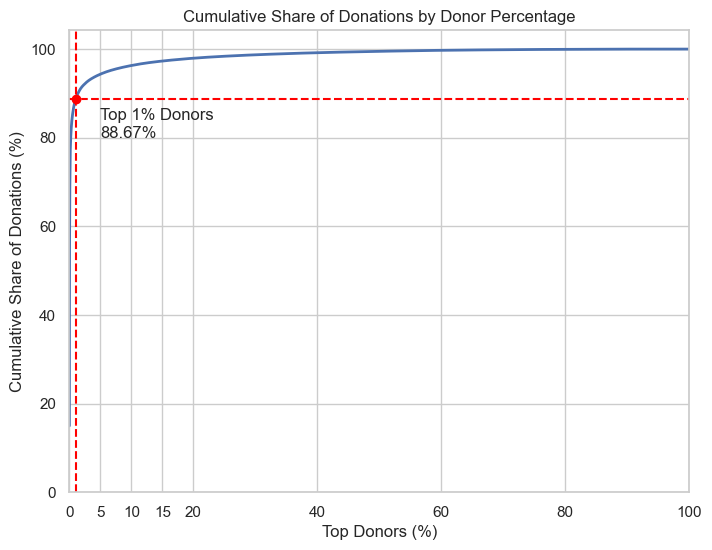

In [32]:
# Contribution of top 1% bar graph cumulative contribution curve
sorted_donors = (
    active_donors["cumulative_donation_amount"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

cum_donations = sorted_donors.cumsum() / sorted_donors.sum() * 100
cum_donors = (
    np.arange(1, len(sorted_donors) + 1)
    / len(sorted_donors)
    * 100
)

top1_percent = 1 / len(sorted_donors) * 100
top1_share = 88.67

plt.figure(figsize=(8,6))

plt.plot(cum_donors, cum_donations, linewidth=2)

plt.axvline(1, color="red", linestyle="--", label="Top 1% of Donors")
plt.axhline(88.67, color="red", linestyle="--")

plt.scatter(1, 88.67, color="red", zorder=5)

plt.title("Cumulative Share of Donations by Donor Percentage")
plt.xlabel("Top Donors (%)")
plt.ylabel("Cumulative Share of Donations (%)")

plt.annotate(
    "Top 1% Donors\n88.67%",
    xy=(top1_percent, top1_share),
    xytext=(5, 80),
    arrowprops=dict(arrowstyle="->")
)

plt.xlim(0, 5)
plt.xticks(np.arange(0, 5.5, 0.5))

plt.xticks([0, 5, 10, 15, 20, 40, 60, 80, 100])
plt.yticks(np.arange(0, 101, 20))


plt.show()

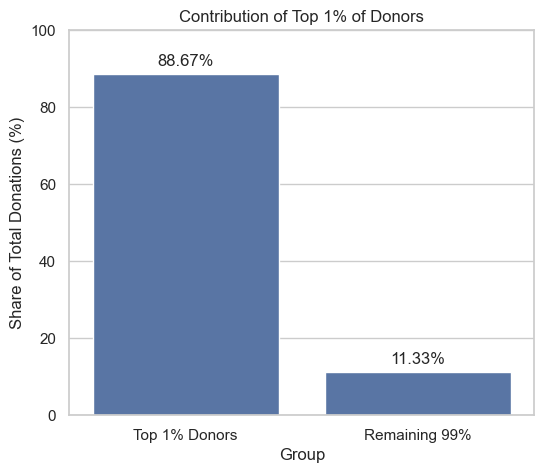

In [33]:
# Contribution of top 1% bar graph
donation_share = pd.DataFrame({
    "Group": ["Top 1% Donors", "Remaining 99%"],
    "Donation Share": [88.67, 11.33]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=donation_share,
    x="Group",
    y="Donation Share"
)

plt.ylabel("Share of Total Donations (%)")
plt.ylim(0,100)

plt.title("Contribution of Top 1% of Donors")

for i, v in enumerate(donation_share["Donation Share"]):
    plt.text(i, v + 2, f"{v:.2f}%", ha="center")

plt.show()

In [34]:
# Calculating the contribution of the top 1% donors
top_10_total = (
    active_donors
    .nlargest(10, "cumulative_donation_amount")["cumulative_donation_amount"]
    .sum()
)

print(
    f"Top 10 donors contribute "
    f"{(top_10_total / total_donations) * 100:.2f}% "
    f"of all cumulative donations."
)

Top 10 donors contribute 60.27% of all cumulative donations.


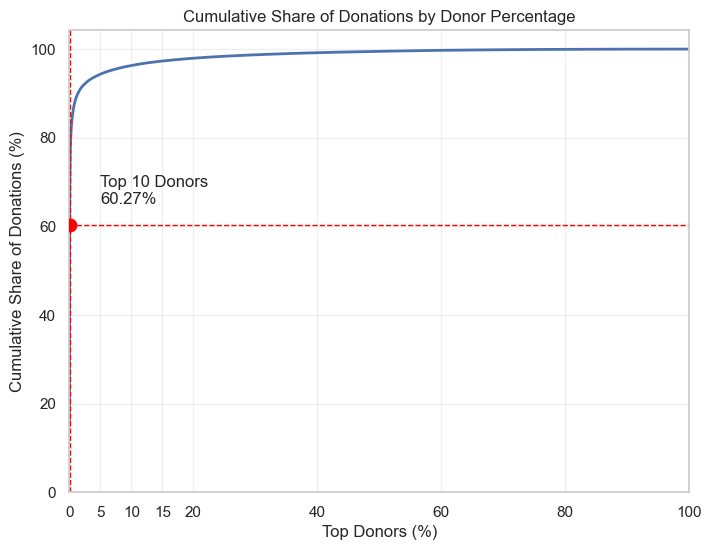

In [35]:
# Contribution of top 10 donors cumulative contribution curve
sorted_donors = (
    active_donors["cumulative_donation_amount"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

cum_donations = sorted_donors.cumsum() / sorted_donors.sum() * 100

cum_donors = (
    np.arange(1, len(sorted_donors) + 1)
    / len(sorted_donors)
    * 100
)

top10_percent = 10 / len(sorted_donors) * 100
top10_share = 60.27

plt.figure(figsize=(8,6))

plt.plot(
    cum_donors,
    cum_donations,
    linewidth=2
)

plt.scatter(
    top10_percent,
    top10_share,
    color="red",
    s=80,
    zorder=5
)

plt.axvline(
    top10_percent,
    color="red",
    linestyle="--",
    linewidth=1
)

plt.axhline(
    top10_share,
    color="red",
    linestyle="--",
    linewidth=1
)

plt.annotate(
    "Top 10 Donors\n60.27%",
    xy=(top10_percent, top10_share),
    xytext=(5, 65),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Cumulative Share of Donations by Donor Percentage")
plt.xlabel("Top Donors (%)")
plt.ylabel("Cumulative Share of Donations (%)")

plt.xlim(0, 5)
plt.xticks(np.arange(0, 5.5, 0.5))

plt.xticks([0, 5, 10, 15, 20, 40, 60, 80, 100])
plt.yticks(np.arange(0, 101, 20))


plt.grid(alpha=0.3)

plt.show()

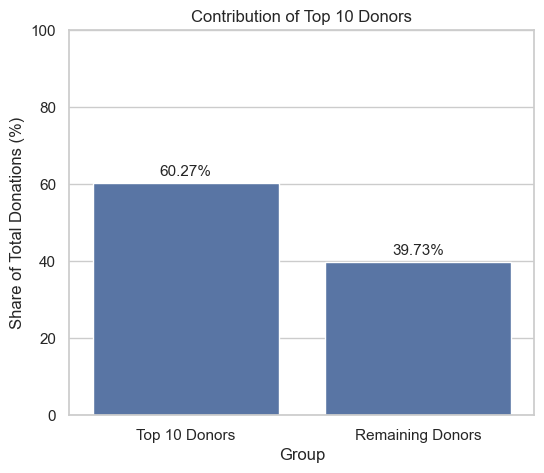

In [36]:
# Contribution of top 10 donors bar graph
donation_share = pd.DataFrame({
    "Group": [
        "Top 10 Donors",
        "Remaining Donors"
    ],
    "Donation Share": [
        60.27,
        39.73
    ]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=donation_share,
    x="Group",
    y="Donation Share"
)

plt.ylabel("Share of Total Donations (%)")
plt.ylim(0,100)

plt.title("Contribution of Top 10 Donors")

for i, value in enumerate(donation_share["Donation Share"]):
    plt.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.show()

## Donation Behavior Observations

### Annual Donation Participation
Donation participation remains relatively low across all fiscal years, with between 5.53% and 7.36% of constituents making a donation in any individual year.
- The highest participation occurred three fiscal years ago: 7.36%
- The current fiscal year has the lowest participation rate: 5.53%

Overall, fewer than one in every 13 constituents donates in a given fiscal year.

### Recurring Donation Behavior
Most constituents are not recurring donors.
- 23,920 (69.53%) did not donate during any of the six fiscal years analyzed.
- 8,195 (23.82%) donated in only one fiscal year.
- Only 481 constituents (1.40%) donated in three or more fiscal years.
- Just 6 constituents donated in all six fiscal years.

These results indicate that consistent long-term giving is relatively uncommon within the dataset.

### Donation Distribution
Donation amounts are highly concentrated among a small number of constituents.

Although the median cumulative donation amount is only $25, a small number of major donors contribute exceptionally large lifetime donations, resulting in a highly right-skewed distribution.

The largest cumulative donation recorded is $12,221,854.

### Major Donor Concentration

Donations are overwhelmingly concentrated among a very small group of major donors.

- The top 1% of donors (214 individuals) contribute 88.67% of all cumulative donations.
- The top 10 donors alone contribute 60.27% of all cumulative donations.

These findings demonstrate that a relatively small number of major donors account for the majority of fundraising revenue.

In [37]:
# Age groups amounts
age_bins = list(range(15, 91, 5)) + [float("inf")]

age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-2)] + ["90+"]

df["age_group"] = pd.cut(
    df["donor_age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_counts = (
    df["age_group"]
    .value_counts()
    .sort_index()
)

age_counts_table = age_counts.reset_index()
age_counts_table.columns = ["Age Range", "Donors Count"]

age_counts_table.style.hide(axis="index")

Age Range,Donors Count
15-20,170
20-25,982
25-30,1524
30-35,1754
35-40,1494
40-45,22369
45-50,1119
50-55,996
55-60,894
60-65,786


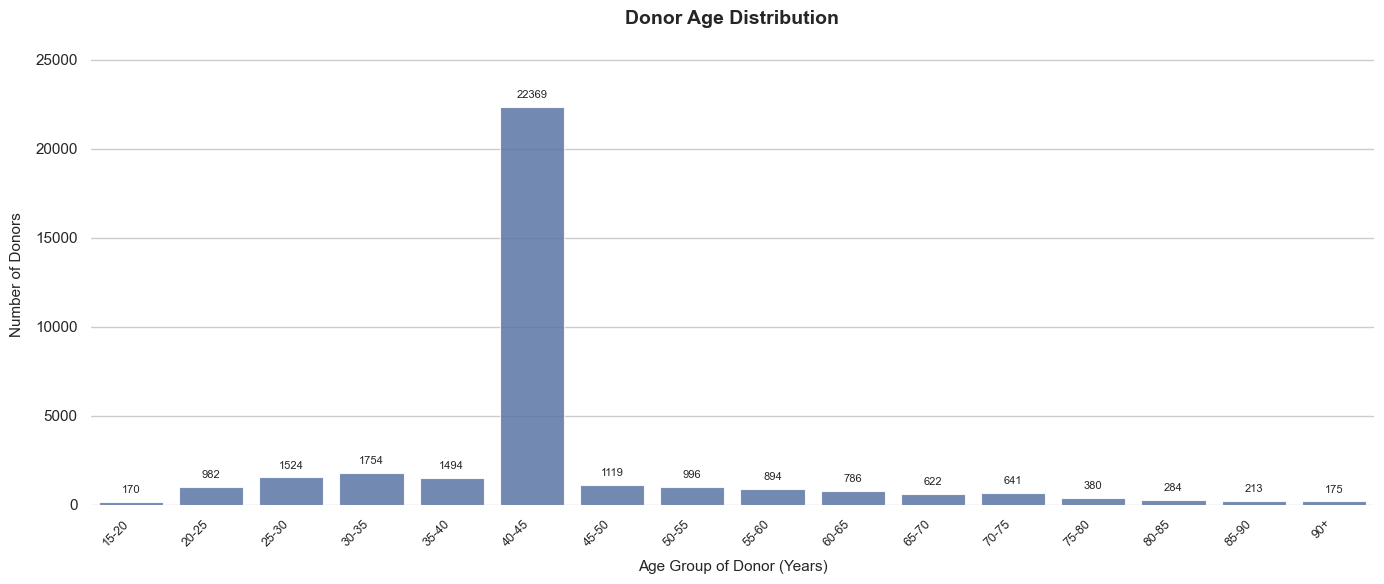

In [38]:
# Donor age distribution bar graph
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x=age_counts.index,
    y=age_counts.values,
    linewidth=0.8,
    alpha=0.85
)

plt.title("Donor Age Distribution", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Age Group of Donor (Years)", fontsize=11, labelpad=8)
plt.ylabel("Number of Donors", fontsize=11, labelpad=8)
plt.xticks(rotation=45, ha="right", fontsize=9)

for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            xy=(patch.get_x() + patch.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_ylim(top=ax.get_ylim()[1] * 1.1)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [39]:
# Donor participation rate by age
historical_rate = (
    df.groupby("age_group", observed=False)["donor_indicator_flag"]
      .mean()
      .mul(100)
      .round(2)
)

historical_rate_table = historical_rate.reset_index()
historical_rate_table.columns = ["Age Range", "Donation Percentage (%)"]

historical_rate_table.style.hide(axis="index")

Age Range,Donation Percentage (%)
15-20,59.410000
20-25,57.130000
25-30,60.500000
30-35,59.750000
35-40,58.500000
40-45,63.230000
45-50,62.650000
50-55,60.140000
55-60,62.640000
60-65,59.800000


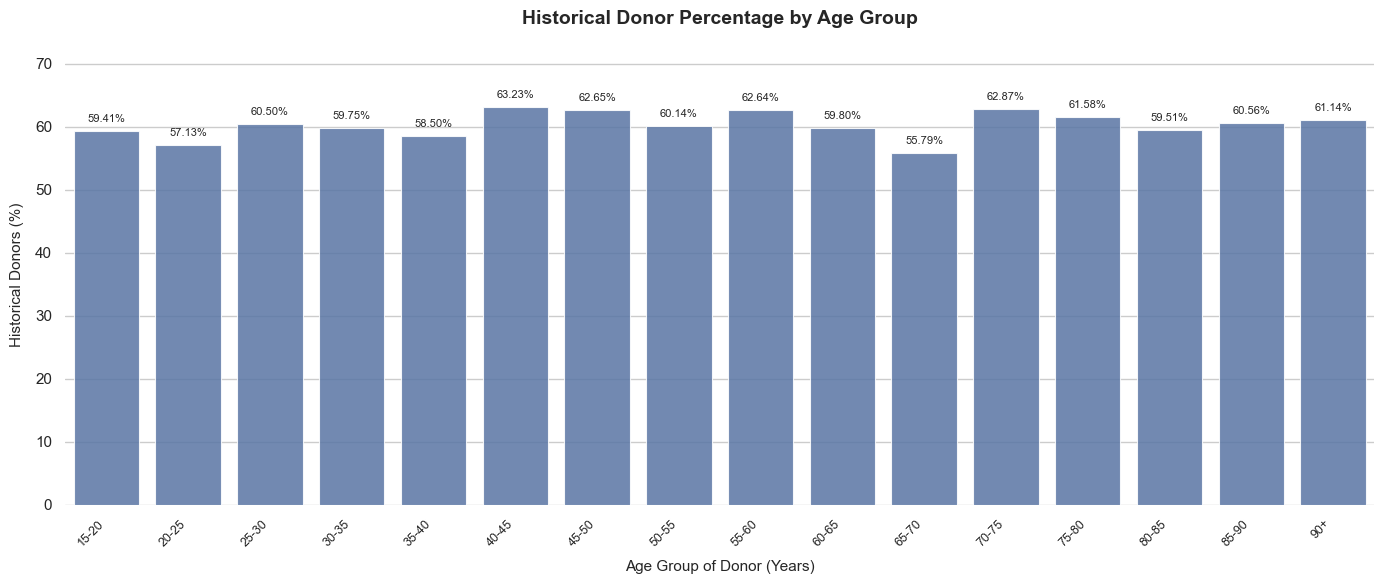

In [40]:
# Donor participation rate by age bar graph
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x=historical_rate.index,
    y=historical_rate.values,
    linewidth=0.8,
    alpha=0.85
)

plt.title("Historical Donor Percentage by Age Group", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Age Group of Donor (Years)", fontsize=11, labelpad=8)
plt.ylabel("Historical Donors (%)", fontsize=11, labelpad=8)
plt.xticks(rotation=45, ha="right", fontsize=9)

for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.2f}%",
            xy=(patch.get_x() + patch.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_ylim(top=ax.get_ylim()[1] * 1.1)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Age Distribution Observations
The constituent population is not evenly distributed across age groups.
- The 40–45 age group contains 22,369 constituents, which represents approximately 65% of the dataset.
- All other age groups contain substantially fewer records, indicating a strong concentration of constituents within this age range.

This unusually large concentration should be considered when interpreting age-related analyses, as it may reflect characteristics of the underlying dataset rather than the overall donor population.

### Historical Donor Status by Age Group
- The percentage of historical donors remains relatively consistent across all age groups, ranging from approximately 55.79% to 63.23%.
- The highest historical donor percentage is observed among constituents aged 40–45 (63.23%), followed closely by the 70–75 (62.87%), 45–50 (62.65%), and 55–60 (62.64%) age groups.
- The 65–70 age group has the lowest historical donor percentage at 55.79%.

Overall, historical donor status does not vary substantially across age groups, suggesting that age alone may not be a strong differentiating factor for historical donation behavior within this dataset.